# Face detect

In [3]:
# pip install opencv-python

  Using cached opencv_python-4.9.0.80-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached opencv_python-4.9.0.80-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (62.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
# pip install torchvision

  Using cached torchvision-0.17.0-cp310-cp310-manylinux1_x86_64.whl.metadata (6.6 kB)
Using cached torchvision-0.17.0-cp310-cp310-manylinux1_x86_64.whl (6.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [6]:
# pip install mediapipe

  Using cached absl_py-2.1.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached flatbuffers-23.5.26-py2.py3-none-any.whl.metadata (850 bytes)
  Using cached opencv_contrib_python-4.9.0.80-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached opt_einsum-3.3.0-py3-none-any.whl (65 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.8/34.8 MB 1.4 MB/s eta 0:00:0000:0100:01
Using cached flatbuffers-23.5.26-py2.py3-none-any.whl (26 kB)
Using cached protobuf-3.20.3-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.1 MB)
Using cached sounddevice-0.4.6-py3-none-any.whl (31 kB)
Using cached absl_py-2.1.0-py3-none-any.whl (133 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 1.2 MB/s eta 0:00:0000:0100:01
Using cached opencv_contrib_python-4.9.0.80-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (68.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.0 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to

# Imports

In [1]:
import os

In [2]:
import cv2
import mediapipe as mp #face detector
import math
import numpy as np
import time

import warnings                         # for pip?
warnings.simplefilter("ignore", UserWarning)

import torch
import torch.nn as  nn
import torch.nn.functional as F
from PIL import Image                   # for pip?
from torchvision import transforms

/home/robert/.pyenv/versions/3.10.6/envs/Music_Selector_Project/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# img video face detect

In [3]:
# from read_video_file_ok.py for push:


########################################################################
#-----------------------------------------------------------------------
# Model Architectures

class Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_channels, out_channels, i_downsample=None, stride=1):
        super(Bottleneck, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0, bias=False)
        self.batch_norm1 = nn.BatchNorm2d(out_channels, eps=0.001, momentum=0.99)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding='same', bias=False)
        self.batch_norm2 = nn.BatchNorm2d(out_channels, eps=0.001, momentum=0.99)

        self.conv3 = nn.Conv2d(out_channels, out_channels*self.expansion, kernel_size=1, stride=1, padding=0, bias=False)
        self.batch_norm3 = nn.BatchNorm2d(out_channels*self.expansion, eps=0.001, momentum=0.99)

        self.i_downsample = i_downsample
        self.stride = stride
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x.clone()
        x = self.relu(self.batch_norm1(self.conv1(x)))

        x = self.relu(self.batch_norm2(self.conv2(x)))

        x = self.conv3(x)
        x = self.batch_norm3(x)

        #downsample if needed
        if self.i_downsample is not None:
            identity = self.i_downsample(identity)
        #add identity
        x+=identity
        x=self.relu(x)

        return x

class Conv2dSame(torch.nn.Conv2d):

    def calc_same_pad(self, i: int, k: int, s: int, d: int) -> int:
        return max((math.ceil(i / s) - 1) * s + (k - 1) * d + 1 - i, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        ih, iw = x.size()[-2:]

        pad_h = self.calc_same_pad(i=ih, k=self.kernel_size[0], s=self.stride[0], d=self.dilation[0])
        pad_w = self.calc_same_pad(i=iw, k=self.kernel_size[1], s=self.stride[1], d=self.dilation[1])

        if pad_h > 0 or pad_w > 0:
            x = F.pad(
                x, [pad_w // 2, pad_w - pad_w // 2, pad_h // 2, pad_h - pad_h // 2]
            )
        return F.conv2d(
            x,
            self.weight,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups,
        )

class ResNet(nn.Module):
    def __init__(self, ResBlock, layer_list, num_classes, num_channels=3):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv_layer_s2_same = Conv2dSame(num_channels, 64, 7, stride=2, groups=1, bias=False)
        self.batch_norm1 = nn.BatchNorm2d(64, eps=0.001, momentum=0.99)
        self.relu = nn.ReLU()
        self.max_pool = nn.MaxPool2d(kernel_size = 3, stride=2)

        self.layer1 = self._make_layer(ResBlock, layer_list[0], planes=64, stride=1)
        self.layer2 = self._make_layer(ResBlock, layer_list[1], planes=128, stride=2)
        self.layer3 = self._make_layer(ResBlock, layer_list[2], planes=256, stride=2)
        self.layer4 = self._make_layer(ResBlock, layer_list[3], planes=512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc1 = nn.Linear(512*ResBlock.expansion, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, num_classes)

    def extract_features(self, x):
        x = self.relu(self.batch_norm1(self.conv_layer_s2_same(x)))
        x = self.max_pool(x)
        # print(x.shape)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc1(x)
        return x

    def forward(self, x):
        x = self.extract_features(x)
        x = self.relu1(x)
        x = self.fc2(x)
        return x

    def _make_layer(self, ResBlock, blocks, planes, stride=1):
        ii_downsample = None
        layers = []

        if stride != 1 or self.in_channels != planes*ResBlock.expansion:
            ii_downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, planes*ResBlock.expansion, kernel_size=1, stride=stride, bias=False, padding=0),
                nn.BatchNorm2d(planes*ResBlock.expansion, eps=0.001, momentum=0.99)
            )

        layers.append(ResBlock(self.in_channels, planes, i_downsample=ii_downsample, stride=stride))
        self.in_channels = planes*ResBlock.expansion

        for i in range(blocks-1):
            layers.append(ResBlock(self.in_channels, planes))

        return nn.Sequential(*layers)

def ResNet50(num_classes, channels=3):
    return ResNet(Bottleneck, [3,4,6,3], num_classes, channels)

class LSTMPyTorch(nn.Module):
    def __init__(self):
        super(LSTMPyTorch, self).__init__()

        self.lstm1 = nn.LSTM(input_size=512, hidden_size=512, batch_first=True, bidirectional=False)
        self.lstm2 = nn.LSTM(input_size=512, hidden_size=256, batch_first=True, bidirectional=False)
        self.fc = nn.Linear(256, 7)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = self.fc(x[:, -1, :])
        x = self.softmax(x)
        return x

#-----------------------------------------------------------------------#
#########################################################################
#|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||#
#########################################################################
#-----------------------------------------------------------------------#
# Sub functions

def pth_processing(fp):
    class PreprocessInput(torch.nn.Module):
        def init(self):
            super(PreprocessInput, self).init()

        def forward(self, x):
            x = x.to(torch.float32)
            x = torch.flip(x, dims=(0,))
            x[0, :, :] -= 91.4953
            x[1, :, :] -= 103.8827
            x[2, :, :] -= 131.0912
            return x

    def get_img_torch(img):

        ttransform = transforms.Compose([
            transforms.PILToTensor(),
            PreprocessInput()
        ])
        img = img.resize((224, 224), Image.Resampling.NEAREST)
        img = ttransform(img)
        img = torch.unsqueeze(img, 0)
        return img
    return get_img_torch(fp)

def tf_processing(fp):
    def preprocess_input(x):
        x_temp = np.copy(x)
        x_temp = x_temp[..., ::-1]
        x_temp[..., 0] -= 91.4953
        x_temp[..., 1] -= 103.8827
        x_temp[..., 2] -= 131.0912
        return x_temp

    def get_img_tf(img):
        img = cv2.resize(img, (224,224), interpolation=cv2.INTER_NEAREST)
        img = tf.keras.utils.img_to_array(img)
        img = preprocess_input(img)
        img = np.array([img])
        return img

    return get_img_tf(fp)

def norm_coordinates(normalized_x, normalized_y, image_width, image_height):

    x_px = min(math.floor(normalized_x * image_width), image_width - 1)
    y_px = min(math.floor(normalized_y * image_height), image_height - 1)

    return x_px, y_px

def get_box(fl, w, h):
    idx_to_coors = {}
    for idx, landmark in enumerate(fl.landmark):
        landmark_px = norm_coordinates(landmark.x, landmark.y, w, h)

        if landmark_px:
            idx_to_coors[idx] = landmark_px

    x_min = np.min(np.asarray(list(idx_to_coors.values()))[:,0])
    y_min = np.min(np.asarray(list(idx_to_coors.values()))[:,1])
    endX = np.max(np.asarray(list(idx_to_coors.values()))[:,0])
    endY = np.max(np.asarray(list(idx_to_coors.values()))[:,1])

    (startX, startY) = (max(0, x_min), max(0, y_min))
    (endX, endY) = (min(w - 1, endX), min(h - 1, endY))

    return startX, startY, endX, endY

def display_EMO_PRED(img, box, label='', color=(128, 128, 128), txt_color=(255, 255, 255), line_width=2, ):
    lw = line_width or max(round(sum(img.shape) / 2 * 0.003), 2)
    text2_color = (255, 0, 255)
    p1, p2 = (int(box[0]), int(box[1])), (int(box[2]), int(box[3]))
    cv2.rectangle(img, p1, p2, text2_color, thickness=lw, lineType=cv2.LINE_AA)
    font = cv2.FONT_HERSHEY_SIMPLEX

    tf = max(lw - 1, 1)
    text_fond = (0, 0, 0)
    text_width_2, text_height_2 = cv2.getTextSize(label, font, lw / 3, tf)
    text_width_2 = text_width_2[0] + round(((p2[0] - p1[0]) * 10) / 360)
    center_face = p1[0] + round((p2[0] - p1[0]) / 2)

    cv2.putText(img, label,
                (center_face - round(text_width_2 / 2), p1[1] - round(((p2[0] - p1[0]) * 20) / 360)), font,
                lw / 3, text_fond, thickness=tf, lineType=cv2.LINE_AA)
    cv2.putText(img, label,
                (center_face - round(text_width_2 / 2), p1[1] - round(((p2[0] - p1[0]) * 20) / 360)), font,
                lw / 3, text2_color, thickness=tf, lineType=cv2.LINE_AA)
    return img

def display_FPS(img, text, margin=1.0, box_scale=1.0):  # frame = display_FPS(frame, 'FPS: {0:.1f}'.format(1 / (t2 - t1)), box_scale=.5)
    img_h, img_w, _ = img.shape
    line_width = int(min(img_h, img_w) * 0.001)  # line width
    thickness = max(int(line_width / 3), 1)  # font thickness

    font_face = cv2.FONT_HERSHEY_SIMPLEX
    font_color = (0, 0, 0)
    font_scale = thickness / 1.5

    t_w, t_h = cv2.getTextSize(text, font_face, font_scale, None)[0]

    margin_n = int(t_h * margin)
    sub_img = img[0 + margin_n: 0 + margin_n + t_h + int(2 * t_h * box_scale),
              img_w - t_w - margin_n - int(2 * t_h * box_scale): img_w - margin_n]

    white_rect = np.ones(sub_img.shape, dtype=np.uint8) * 255

    img[0 + margin_n: 0 + margin_n + t_h + int(2 * t_h * box_scale),
    img_w - t_w - margin_n - int(2 * t_h * box_scale):img_w - margin_n] = cv2.addWeighted(sub_img, 0.5, white_rect, .5,
                                                                                          1.0)

    cv2.putText(img=img,
                text=text,
                org=(img_w - t_w - margin_n - int(2 * t_h * box_scale) // 2,
                     0 + margin_n + t_h + int(2 * t_h * box_scale) // 2),
                fontFace=font_face,
                fontScale=font_scale,
                color=font_color,
                thickness=thickness,
                lineType=cv2.LINE_AA,
                bottomLeftOrigin=False)

    return img
#-----------------------------------------------------------------------#
#########################################################################
#|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||#
#########################################################################
#-----------------------------------------------------------------------#
# Testing Models:

def input_file_proc(input_file):
    """
    Takes the input file (photo or video) from the UI.
    If input is a photo, a video version is saved to
        the current working directory.
    If input is a video, it is process-ready.
    Returns a video file name of string type.
    """

    dot_locate = input_file.find('.')

    READABLE_IMGS = [
        ".bmp", ".dib",     # Windows bitmaps – *.bmp, *.dib
        ".jpeg", ".jpg" ,   # JPEG files – *.jpeg, *.jpg
        ".png",             # Portable Network Graphics – *.png
        ".webp",            # WebP – *.webp
        ".sr", ".ras",      # Sun rasters – *.sr, *.ras
        ".tiff", "tif"      # TIFF files – *.tiff, *.tif
        # Raster and Vector geospatial data supported by GDAL
    ]

    # Determine input file type (video or photo)
    ## If input is a photo, convert to video and save as input_file.avi
    if input_file[dot_locate:] in READABLE_IMGS:
        img_array = []
        img = cv2.imread(input_file)
        height, width, layers = img.shape
        size = (width,height)
        img_array.append(img)
        out = cv2.VideoWriter('input_file.avi',
                              cv2.VideoWriter_fourcc(*'DIVX'),
                              15,
                              size
                              )
        for i in range(len(img_array)):
            out.write(img_array[i])
        out.release()
        return 'input_file.avi'
    else: return input_file

def extract_emotion(input_file, pth_backbone_model, lstm_features):
    """
    The input video is analyzed by the model detecting face emotion/s.
    Returns a tuple of dictionaries:
        video_emotions
            (a histogram of the emotions)
            keys: the detected emotions in the video.
            values: key count.
        emotions_weight
            keys: the detected emotions in the video.
            values:
                list of probability values of the key;
                each item corresponds to 1 photo/frame in the video.
    """
    time_limit = 10  # seconds
    start_time = time.time()

    cap = cv2.VideoCapture(input_file)

    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = np.round(cap.get(cv2.CAP_PROP_FPS))

    # dictionary histogram of the indentified face emotion
    video_emotions = {}
    # dictionary with value for each identified face emotion
    emotions_weight = {}

    with mp_face_mesh.FaceMesh(
    max_num_faces=1,
    refine_landmarks=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5) as face_mesh:
        while cap.isOpened() and (time.time() - start_time) < time_limit:
            t1 = time.time()
            success, frame = cap.read()
            if frame is None:
                break
            frame_copy = frame.copy()
            frame_copy.flags.writeable = False
            frame_copy = cv2.cvtColor(frame_copy, cv2.COLOR_BGR2RGB)
            results = face_mesh.process(frame_copy)
            frame_copy.flags.writeable = True
# Note: process photos directly when time permits.
            if results.multi_face_landmarks:
                for fl in results.multi_face_landmarks:
                    startX, startY, endX, endY  = get_box(fl, w, h)
                    cur_face = frame_copy[startY:endY, startX: endX]
                    cur_face = pth_processing(Image.fromarray(cur_face))
                    # features = torch.nn.functional.relu(pth_backbone_model.extract_features(cur_face)).detach().numpy()
                    features = F.relu(
                        pth_backbone_model.extract_features(
                            cur_face
                            )
                        ).detach().numpy()

                    if len(lstm_features) == 0:
                        lstm_features = [features]*10
                    else:
                        lstm_features = lstm_features[1:] + [features]
                    lstm_f = torch.from_numpy(np.vstack(lstm_features))
                    lstm_f = torch.unsqueeze(lstm_f, 0)
                    output = pth_LSTM_model(lstm_f).detach().numpy()
                    cl = np.argmax(output)
                    label = DICT_EMO[cl]

                    # populate the dictionaries
                    video_emotions[label] = video_emotions.get(label, 0) + 1
                    emotions_weight[label] = emotions_weight.get(label, []) + [round(output[0][cl], 2)]

                    frame = display_EMO_PRED(frame, (startX, startY, endX, endY), label+' {0:.1%}'.format(output[0][cl]), line_width=3)

            t2 = time.time()

            frame = display_FPS(frame, 'FPS: {0:.1f}'.format(1 / (t2 - t1)), box_scale=.5)  # Upper right corner tag display "FPS: x.x"

            cv2.imshow('Webcam', frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("quit")
                break

        ######################################################
        ################ F O R    S A N I T Y ################
        ######################################################
        #----------------------------------------------------#
        print("Ended successfully")
        print(f"video_emotions:\n{video_emotions}")
        print(f"emotions_weight:\n{emotions_weight}")
        for k,v in emotions_weight.items():
            print(k, v)
            print(f'Max {k} probability: {max(v)}')
        #----------------------------------------------------#
        ######################################################
        ######################################################
        ######################################################

        cap.release()
        cv2.destroyAllWindows()
    return video_emotions, emotions_weight
#-----------------------------------------------------------------------#
#########################################################################
#|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||#
#########################################################################
#-----------------------------------------------------------------------#
# Testing Models by image file

mp_face_mesh = mp.solutions.face_mesh

name_backbone_model = 'FER_static_ResNet50_AffectNet.pt'
# name_LSTM_model = 'IEMOCAP'
# name_LSTM_model = 'CREMA-D'
# name_LSTM_model = 'RAMAS'
# name_LSTM_model = 'RAVDESS'
# name_LSTM_model = 'SAVEE'
name_LSTM_model = 'Aff-Wild2'

# torch

pth_backbone_model = ResNet50(7, channels=3)
pth_backbone_model.load_state_dict(torch.load(name_backbone_model))
pth_backbone_model.eval()

pth_LSTM_model = LSTMPyTorch()
pth_LSTM_model.load_state_dict(torch.load('FER_dinamic_LSTM_{0}.pt'.format(name_LSTM_model)))
pth_LSTM_model.eval()


DICT_EMO = {
    0: 'Neutral',
    1: 'Happiness',
    2: 'Sadness',
    3: 'Surprise',
    4: 'Fear',
    5: 'Disgust',
    6: 'Anger'
}

######################################################
#----------------------------------------------------#
# From_Krystia_Streamlit_image_or_video:
    # variable name: input_file
    # content: photo or video
        # ① captured = camera_input
        # ② upload = browse (drag-drop)


# DETERMINE input_file type:
## testing files:
input_file = 'IMG_5221.MOV'  # 'IMG_0535.mov'  # 'facess.png'  # 'face.tif'  # 'face.jpg'  # 'face.png'  # 'IMG_5221.MOV'  # IMG_0509.MOV  # image_file

# Received from Krystia's UI
input_file = input_file
lstm_features = []



input_file = input_file_proc(input_file)  # video version of the photo or just the video input as is


In [4]:
input_file


'IMG_5221.MOV'

In [5]:

#-----------------------------------------------------------------------#
#########################################################################
#|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||#
#########################################################################
#-----------------------------------------------------------------------#
# Testing Models by video file

extract_emotion(input_file, pth_backbone_model, lstm_features)

#-----------------------------------------------------------------------#
#########################################################################
#|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||#
#########################################################################
#-----------------------------------------------------------------------#


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


: 

In [6]:
print(cv2.getBuildInformation())


General configuration for OpenCV 4.9.0 =====================================
  Version control:               4.9.0

  Platform:
    Timestamp:                   2023-12-31T11:19:01Z
    Host:                        Linux 5.15.0-1053-azure x86_64
    CMake:                       3.28.1
    CMake generator:             Unix Makefiles
    CMake build tool:            /bin/gmake
    Configuration:               Release

  CPU/HW features:
    Baseline:                    SSE SSE2 SSE3
      requested:                 SSE3
    Dispatched code generation:  SSE4_1 SSE4_2 FP16 AVX AVX2 AVX512_SKX
      requested:                 SSE4_1 SSE4_2 AVX FP16 AVX2 AVX512_SKX
      SSE4_1 (16 files):         + SSSE3 SSE4_1
      SSE4_2 (1 files):          + SSSE3 SSE4_1 POPCNT SSE4_2
      FP16 (0 files):            + SSSE3 SSE4_1 POPCNT SSE4_2 FP16 AVX
      AVX (8 files):             + SSSE3 SSE4_1 POPCNT SSE4_2 AVX
      AVX2 (36 files):           + SSSE3 SSE4_1 POPCNT SSE4_2 FP16 FMA3 AVX AVX2
  

In [7]:
# Displays the location of the package files in site-packages:
cv2.__file__  # '/home/robert/.pyenv/versions/3.10.6/envs/Music_Selector_Project/lib/python3.10/site-packages/cv2/__init__.py'

'/home/robert/.pyenv/versions/3.10.6/envs/Music_Selector_Project/lib/python3.10/site-packages/cv2/__init__.py'

**[python: OpenCV Root Directory](https://stackoverflow.com/questions/15227532/python-opencv-root-directory)**

You can use cv2.__file__ to get path to the module and then use os.path to resolve symlinks and do some path manipulation.
- '/home/robert/.pyenv/versions/3.10.6/envs/Music_Selector_Project/lib/python3.10/site-packages/cv2/__init__.py'



**[re-run cmake or configure script in function cvShowImage](https://github.com/opencv/opencv/issues/8537)**
Here the steps I make to make GUI functions work

Uninstalling OpenCV
sudo apt-get purge libopencv*
sudo dpkg -r opencv

Check
sudo dpkg -r opencv

Then, go to the build directory and
sudo make uninstall

After, you can rebuild with this make command
cmake -DCMAKE_BUILD_TYPE=RELEASE -DCMAKE_INSTALL_PREFIX=/usr/local -DFORCE_VTK=ON -DWITH_TBB=ON -DWITH_V4L=ON -DWITH_QT=ON -DWITH_OPENGL=ON -DWITH_CUBLAS=ON -DCUDA_NVCC_FLAGS="-D_FORCE_INLINES" -DWITH_GDAL=ON -DWITH_XINE=ON -DBUILD_EXAMPLES=ON ..

And then, finally
sudo make install

The pages that guided me:
- [Uninstalling OpenCV](http://www.srccodes.com/p/article/56/uninstall-remove-opencv-raspberry-pi-jessie-debain-make-uninstall-open-source-computer-vision-opencvlib)
- [Installing OpenCV 3.2 on Ubuntu 16.04](https://github.com/BVLC/caffe/wiki/OpenCV-3.2-Installation-Guide-on-Ubuntu-16.04)


# [Creating Video from Images using OpenCV-Python](https://theailearner.com/2018/10/15/creating-video-from-images-using-opencv-python/)


In this blog, we will do a small project using OpenCV-Python where we will be creating video from image sequences. This project is entirely based on what we read in Chapter 1 and 2. Let’s start

**Steps:**

1. Fetch all the image file names using glob
2. Read all the images using cv2.imread()
3. Store all the images into a list
4. Create a VideoWriter object using cv2.VideoWriter()
5. Save the images to video file using cv2.VideoWriter().write()
6. Release the VideoWriter and destroy all windows.

**Let’s see the code:**

In [ ]:
# import cv2
# import numpy as np
# import glob

# img_array = []
# for filename in glob.glob('C:/New folder/Images/*.jpg'):
#     img = cv2.imread(filename)
#     height, width, layers = img.shape
#     size = (width,height)
#     img_array.append(img)


# out = cv2.VideoWriter('project.avi',cv2.VideoWriter_fourcc(*'DIVX'), 15, size)

# for i in range(len(img_array)):
#     out.write(img_array[i])
# out.release()

**glob.glob(Pathname)** fetches all the filenames present in that path. **‘*.jpg’** means all the jpg files. So, in code glob.glob() fetches the filename of all the jpg files present in that path.

In [1]:
import os

In [30]:
marker = 0
pckg = {}

with open('pypips.txt', 'r') as f:
    for line in f:
        if "------" in line:
            marker += 1
            pckg[marker] = pckg.get(marker, [])
        elif line == '\n' or line.startswith('#'):
            continue
        if marker:
            pckg[marker] = pckg.get(marker, []) + [line.strip()]

rob = []
for v in pckg[1]:
    rob.append(v.split())
dai = []
for v in pckg[2]:
    dai.append(v.split())
dem = []
for v in pckg[3]:
    dem.append(v.split())


In [42]:
# pckg[3]
# dem

In [43]:

common_rob_dai = {}
for v in rob:
    for val in dai:
        if v[0].isalpha() and v[0] == val[0]:
            common_rob_dai[v[0]] = common_rob_dai.get(v[0], v[1])

common_rob_dem = {}
for v in rob:
    for val in dem:
        if v[0].isalpha() and v[0] == val[0]:
            common_rob_dem[v[0]] = common_rob_dem.get(v[0], v[1])


rob_pckg = {}
for v in rob:
    rob_pckg[v[0]] = rob_pckg.get(v[0], v[1])

dai_pckg = {}
for v in rob:
    dai_pckg[v[0]] = dai_pckg.get(v[0], v[1])

dem_pckg = {}
for v in dem:
    dem_pckg[v[0]] = dem_pckg.get(v[0], v[1])

In [44]:
print(f'len rob: {len(rob)}\nlen dai: {len(dai)}\nlen dem: {len(dem)}')
print(f'rob common dai: {len(common_rob_dai)}\ndai: {len(dai_pckg)}')
print(f'rob common demo: {len(common_rob_dem)}\ndem: {len(dem_pckg)}')

len rob: 166
len dai: 238
len dem: 289
rob common dai: 96
dai: 166
rob common demo: 96
dem: 289


In [45]:
count = 0
for k in common_rob_dem.keys():
    if k in dai_pckg.keys() and common_rob_dem[k] == dem_pckg[k]:
        count += 1
        print(count, 'same')
    else:
        count += 1
        print(count,
              f'{k} \t {common_rob_dem[k]} : {dem_pckg[k]}'
             )

1 anyio 	 4.1.0 : 3.6.2
2 asttokens 	 2.4.1 : 2.0.8
3 same
4 attrs 	 23.1.0 : 22.1.0
5 Babel 	 2.13.1 : 2.10.3
6 bleach 	 6.1.0 : 5.0.1
7 cachetools 	 5.3.2 : 5.2.0
8 certifi 	 2023.11.17 : 2022.9.24
9 cffi 	 1.16.0 : 1.15.1
10 click 	 8.1.7 : 8.1.3
11 colorama 	 0.4.6 : 0.4.5
12 cycler 	 0.12.1 : 0.11.0
13 deap 	 1.4.1 : 1.3.3
14 debugpy 	 1.8.0 : 1.6.3
15 same
16 same
17 same
18 executing 	 2.0.1 : 1.1.1
19 fastjsonschema 	 2.19.0 : 2.16.2
20 same
21 flatbuffers 	 23.5.26 : 22.9.24
22 fonttools 	 4.43.1 : 4.38.0
23 fsspec 	 2023.12.1 : 2022.10.0
24 gast 	 0.5.4 : 0.4.0
25 same
26 grpcio 	 1.60.0 : 1.50.0
27 idna 	 3.6 : 3.4
28 ipykernel 	 6.27.1 : 6.15.3
29 ipython 	 8.18.1 : 8.5.0
30 jedi 	 0.19.1 : 0.18.1
31 joblib 	 1.3.2 : 1.1.1
32 jsonschema 	 4.20.0 : 4.16.0
33 jupyterlab 	 4.0.9 : 3.4.8
34 keras 	 2.15.0 : 2.10.0
35 kiwisolver 	 1.4.5 : 1.4.4
36 libclang 	 16.0.6 : 14.0.6
37 lxml 	 5.1.0 : 4.9.1
38 Markdown 	 3.5.1 : 3.4.1
39 MarkupSafe 	 2.1.3 : 2.1.1
40 matplotlib 	 3.8.0 : 

Why should i use the product?

What Data Science skills can we showcase.


Demo Slide

Story
- 


Reason to use
- differences input
- 


Future Plans
- real time input
- eyebrow control


Arron:
- Robert: Torch for fine tuning the hugging face model


Data Science Skill Demo:
- Daisuke: after the slides, tackle the model
- Krystia: after streamlit



Daisuke's suggestion via slack message

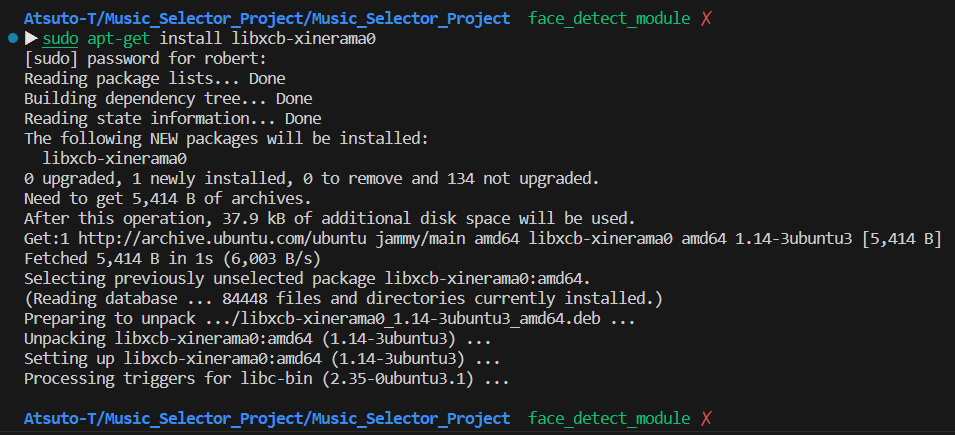

# Atsuto

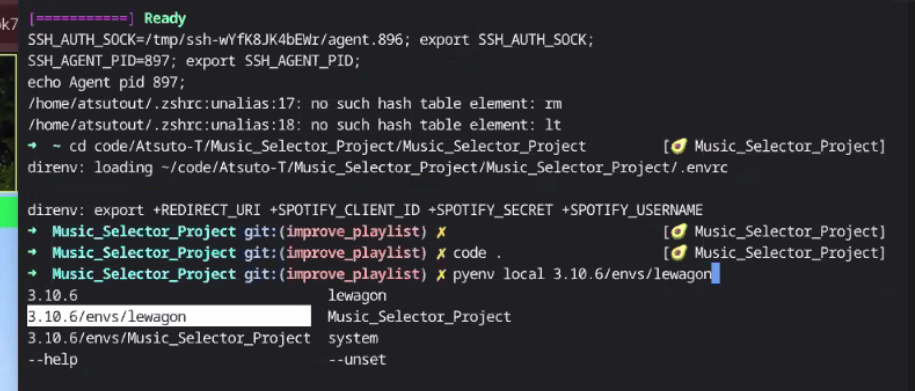

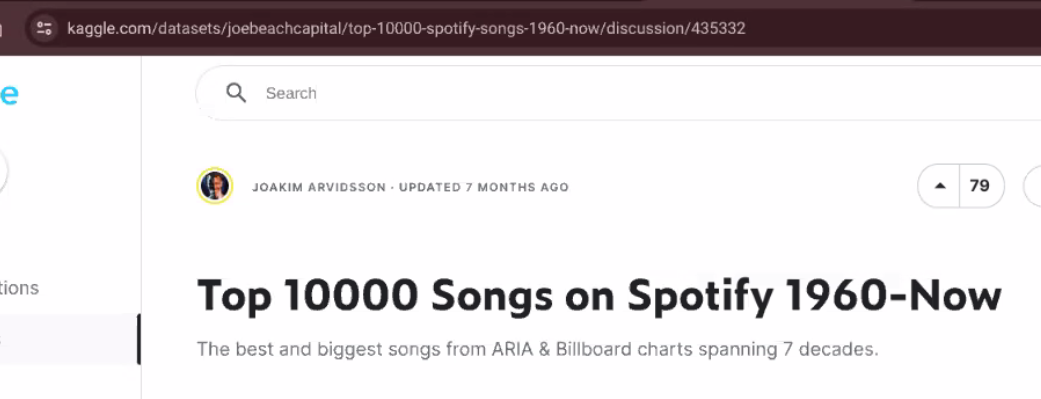

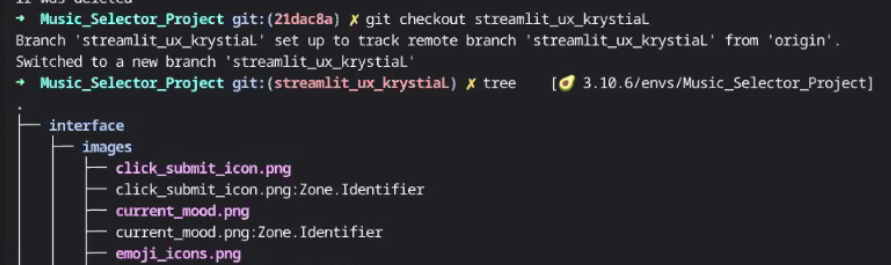

# Krystia

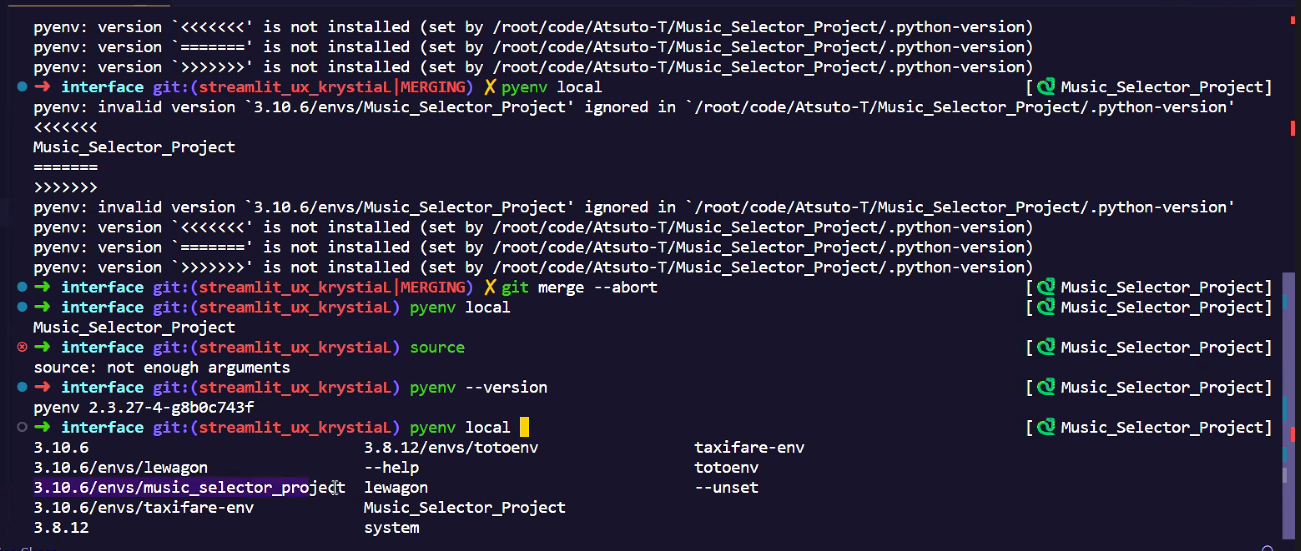